In [1]:
import os
import sys
import argparse

import numpy as np
import torch

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

In [2]:
from data_generation.differential_equations import ElasticityLeastSquares
from utils import load_yaml, load_pkl, load_npy, format_elapsed_time, timing, plot_complex_valued_function, plot_real_valued_function
from utils import evaluate_expression


import scifem
from scifem import create_real_functionspace

import torch
import numpy as np
from petsc4py import PETSc

from utils import save_npy
import matplotlib.pyplot as plt

----------------------------------------
2026-03-01 14:18:55 - Start Program
----------------------------------------


In [3]:
mesh_config_path= repo_path + "/configs/elasticity/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/elasticity/config_data/config_function_space.yaml"
train_dataset_path = repo_path + "/results/elasticity/train_dataset"
test_dataset_path = repo_path + "/results/elasticity/test_dataset"

In [4]:
mesh_args = load_yaml(mesh_config_path)
mesh_args['num_x'], mesh_args['num_y'] = 256, 128
function_space_args = load_yaml(function_space_config_path)
elasticity_least_squares = ElasticityLeastSquares(mesh_args, function_space_args)

mesh = elasticity_least_squares.mesh
Vh = elasticity_least_squares.Vh

dolfin_mesh_coords = load_npy(train_dataset_path + "/mesh_coordinates_256x128.npy")
dolfinx_mesh_coords = mesh.geometry.x[:,:2]
perm = [np.where((dolfin_mesh_coords == row).all(axis=1))[0][0] for row in dolfinx_mesh_coords]

In [5]:
for dataset_path in [train_dataset_path, test_dataset_path]:
    p_vertex_values = load_npy(dataset_path + "/p_vertex_values_256x128.npy")
    
    scale = 2
    image_p_vertex_values = p_vertex_values.reshape(-1, mesh_args['num_y'] + 1, mesh_args['num_x'] + 1)
    downsampled_image_p_vertex_values = image_p_vertex_values[:, ::scale, ::scale]
    downsampled_num_y, downsampled_num_x = downsampled_image_p_vertex_values.shape[1] - 1, downsampled_image_p_vertex_values.shape[2] - 1
    downsampled_p_vertex_values = downsampled_image_p_vertex_values.reshape(-1, (downsampled_num_y + 1) * (downsampled_num_x + 1))
    downsampled_dolfin_mesh_coords = dolfin_mesh_coords.reshape(mesh_args['num_y'] + 1, mesh_args['num_x'] + 1, 2)[::scale, ::scale, :].reshape(-1, 2)
    save_npy(dataset_path + "/p_vertex_values.npy", downsampled_p_vertex_values)
    save_npy(dataset_path + "/mesh_coordinates.npy", downsampled_dolfin_mesh_coords)
    print(f"Saved downsampled p_vertex_values with shape: {downsampled_p_vertex_values.shape}")


Saved downsampled p_vertex_values with shape: (5000, 8385)
Saved downsampled p_vertex_values with shape: (500, 8385)


In [6]:
for dataset_path in [train_dataset_path, test_dataset_path]:
    p_vertex_values = load_npy(dataset_path + "/p_vertex_values_256x128.npy")

    num_functions = len(p_vertex_values)
    p_dim = dolfinx.fem.Function(Vh['p']).x.array.shape[0]
    p_dof = np.zeros((num_functions, p_dim), dtype=np.float64)

    for i in range(num_functions):
        p_fc = dolfinx.fem.Function(Vh['p'])
        p_fc.x.array[:] = p_vertex_values[i].flatten(order='F')[perm][scifem.dof_to_vertexmap(Vh['p'])]
        p_dof[i] = p_fc.x.array[:]

    save_npy(dataset_path + "/p_dof_256x128.npy", p_dof)


In [7]:
mesh_args = load_yaml(mesh_config_path)
mesh_args['num_x'], mesh_args['num_y'] = 128, 64
function_space_args = load_yaml(function_space_config_path)
elasticity_least_squares = ElasticityLeastSquares(mesh_args, function_space_args)
mesh = elasticity_least_squares.mesh
Vh = elasticity_least_squares.Vh

dolfin_mesh_coords = load_npy(train_dataset_path + "/mesh_coordinates.npy")
dolfinx_mesh_coords = mesh.geometry.x[:,:2]
perm = [np.where((dolfin_mesh_coords == row).all(axis=1))[0][0] for row in dolfinx_mesh_coords]

In [8]:
for dataset_path in [train_dataset_path, test_dataset_path]:
    p_vertex_values = load_npy(dataset_path + "/p_vertex_values.npy")

    num_functions = len(p_vertex_values)
    p_dim = dolfinx.fem.Function(Vh['p']).x.array.shape[0]
    p_dof = np.zeros((num_functions, p_dim), dtype=np.float64)

    for i in range(num_functions):
        p_fc = dolfinx.fem.Function(Vh['p'])
        p_fc.x.array[:] = p_vertex_values[i].flatten(order='F')[perm][scifem.dof_to_vertexmap(Vh['p'])]
        p_dof[i] = p_fc.x.array[:]

    save_npy(dataset_path + "/p_dof.npy", p_dof)

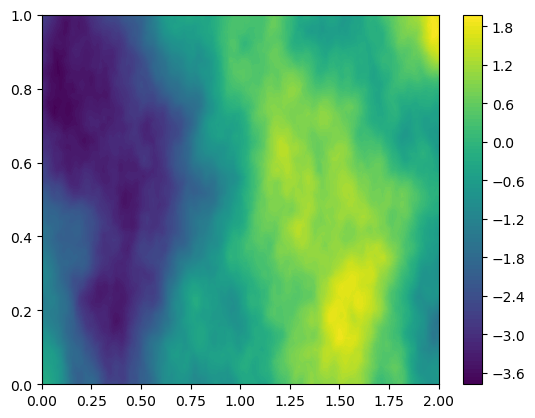

In [9]:
x = mesh.geometry.x[:, 0]
y = mesh.geometry.x[:, 1]
plt.tricontourf(x, y, evaluate_expression(mesh, p_fc, mesh.geometry.x)[1][:, 0], cmap='viridis', levels=100)
plt.colorbar()
plt.show()

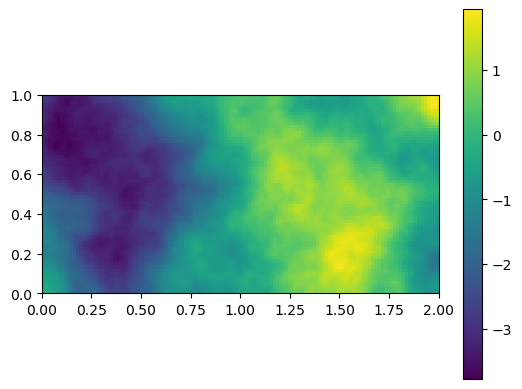

In [10]:
plt.imshow(p_vertex_values[-1].reshape(mesh_args['num_y'] + 1, mesh_args['num_x'] + 1), origin='lower', cmap='viridis', extent=(0, mesh_args['upper_right_x'], 0, mesh_args['upper_right_y']))
plt.colorbar()
plt.show()